# Staggered Evacuation Sensitivity Analysis

This notebook performs sensitivity analysis on staggered EV evacuation using three Beta distribution scenarios:
1. **early_evac** (α=2, β=5): Early evacuation spike
2. **delayed_evac** (α=5, β=2): Delayed evacuation
3. **uniform_evac** (α=1, β=1): Uniform evacuation

The staggered start parameter R_{ilt} represents the number of EVs entering the network at location i with charge level l at time t.


In [1]:
# A tiny test before running the entire code
import pyomo.environ as pe
import pyomo.opt as po

solver = po.SolverFactory("gurobi")
print("Gurobi available:", solver.available())


Gurobi available: True


In [2]:
import pyomo.environ as pe
import pyomo.opt as po
from pyomo.opt import SolverFactory
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import pandas as pd
import time
import math
import os
import sys

# Add code directory to path to import distributions module
sys.path.insert(0, '../code')
from distributions import StaggeredEvacuationDistributions


In [3]:
solver = po.SolverFactory('gurobi')
# Set the environment variable for the license file if needed
# os.environ['GRB_LICENSE_FILE'] = '/path/to/your/gurobi.lic'


In [4]:
# Path definition
Inputpath = "../input/"
Outputpath = "../output/numerical_results/"


In [5]:
# Basic fixed parameters
L = 27  # Number of charge levels (196/7.5)
T = 2   # Evacuation time window
G = 3.7 # Cost of charging capacity installed at each node (million $/thousand cars)
B = 10  # Budget (million $)

# Load network data
df_arc = pd.read_excel(os.path.join(Inputpath, "arcs_sonoma_15min.xlsx"), header=0)
df_node = pd.read_excel(os.path.join(Inputpath, "nodes_sonoma_15min.xlsx"), header=0)
df_char_damFac = pd.read_csv(os.path.join(Inputpath, "charging_cap_damFac_3hrs.csv"), header=0)
df_road_damFac = pd.read_csv(os.path.join(Inputpath, "road_cap_damFac_3hrs.csv"), header=0)
df_S_nodes = pd.read_excel(os.path.join(Inputpath, "safe_nodes_15min.xlsx"), header=0)
df_S_nodes = df_S_nodes[df_S_nodes['Safe'] == 1]


In [6]:
# Get scenario probabilities
cases_num = max(df_char_damFac['Scenario'])
prob_dict = dict()
for k in range(cases_num):
    prob_dict[k] = df_char_damFac.groupby(['Scenario']).first()['Probability'][k+1]
print(f"Number of scenarios: {cases_num}")
print(f"Scenario probabilities: {prob_dict}")


Number of scenarios: 20
Scenario probabilities: {0: np.float64(0.05), 1: np.float64(0.05), 2: np.float64(0.05), 3: np.float64(0.05), 4: np.float64(0.05), 5: np.float64(0.05), 6: np.float64(0.05), 7: np.float64(0.05), 8: np.float64(0.05), 9: np.float64(0.05), 10: np.float64(0.05), 11: np.float64(0.05), 12: np.float64(0.05), 13: np.float64(0.05), 14: np.float64(0.05), 15: np.float64(0.05), 16: np.float64(0.05), 17: np.float64(0.05), 18: np.float64(0.05), 19: np.float64(0.05)}


## Define Network Sets and Parameters


In [7]:
# Define network sets
# The set of nodes in the safety area
N_s = set()
for i in range(len(df_S_nodes)):
    N_s.add(df_S_nodes.iloc[i]['Nodes'])

# Set of all nodes
N = set()
for i in range(len(df_node)):
    N.add(df_node['Nodes'][i])

# Set of arcs and road capacity
A = set()
road_cap = dict()

for i in range(len(df_arc)):
    node0 = df_arc['From'][i]
    node1 = df_arc['To'][i]
    A.add((node0, node1))
    road_cap[((node0, node1))] = df_arc['Capacity'][i]

print(f"Number of nodes: {len(N)}")
print(f"Number of safe nodes: {len(N_s)}")
print(f"Number of arcs: {len(A)}")


Number of nodes: 26
Number of safe nodes: 4
Number of arcs: 64


In [8]:
# Define incoming and outgoing arc sets for each node
Vi = defaultdict(set)
Vo = defaultdict(set)
for (i, j) in A:
    Vi[j].add(i)  # incoming set
    Vo[i].add(j)  # outgoing set


In [9]:
# Stochastic parameters: road capacity
def c_random(A, df_road_damFac, cases_num, road_cap, T):
    c_tuple = dict()
    gk = df_road_damFac.groupby(['Scenario'])

    for k in range(cases_num):
        sce_sub = gk.get_group(k+1).copy()
        for r in range(sce_sub.shape[0]):
            curr_edge = sce_sub.iloc[r]
            for t in range(4*T+1):
                if math.isnan(curr_edge['Time']):
                    c_tuple[((int(curr_edge['From']), int(curr_edge['To'])), k), t] = road_cap[(int(curr_edge['From']), int(curr_edge['To']))]
                elif t/4 < curr_edge['Time']:
                    c_tuple[((int(curr_edge['From']), int(curr_edge['To'])), k), t] = road_cap[(int(curr_edge['From']), int(curr_edge['To']))]
                else:
                    c_tuple[((int(curr_edge['From']), int(curr_edge['To'])), k), t] = 0
    return c_tuple


In [10]:
# Stochastic parameters: charging capacity factors
def s_random(df_char_damFac, cases_num, T):
    xi_s = dict()
    gk = df_char_damFac.groupby(['Scenario'])

    for k in range(cases_num):
        sce_sub = gk.get_group(k+1).copy()
        for r in range(sce_sub.shape[0]):
            curr_node = sce_sub.iloc[r]
            for t in range(4*T+1):
                if math.isnan(curr_node['Time']):
                    xi_s[(int(curr_node['Nodes']), k), t] = 1
                elif t/4 < curr_node['Time']:
                    xi_s[(int(curr_node['Nodes']), k), t] = 1
                else:
                    xi_s[(int(curr_node['Nodes']), k), t] = 0
    return xi_s


In [11]:
road_ca = c_random(A, df_road_damFac, cases_num, road_cap, T)  # road capacity random parameter
xi_s = s_random(df_char_damFac, cases_num, T)  # charging capacity random parameter


/var/folders/w6/hlw3gptn62s2rz_xj4tjg3tc0000gn/T/ipykernel_98866/1150896916.py:7: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  sce_sub = gk.get_group(k+1).copy()


## Define Staggered Evacuation Scenarios


In [12]:
# Define staggered evacuation scenarios with flexible parameters
scenarios = {
    "early_evac": {"alpha": 2, "beta": 5},    # Right-skewed: early evacuation spike
    "delayed_evac": {"alpha": 5, "beta": 2},  # Left-skewed: delayed evacuation
    "uniform_evac": {"alpha": 1, "beta": 1}   # Uniform staggered evacuation
}

print("Staggered Evacuation Scenarios:")
for scenario_name, params in scenarios.items():
    print(f"  {scenario_name}: α={params['alpha']}, β={params['beta']}")


Staggered Evacuation Scenarios:
  early_evac: α=2, β=5
  delayed_evac: α=5, β=2
  uniform_evac: α=1, β=1


## Generate R_ilt Distributions and Statistics


In [13]:
# Load car initialization data (example with even battery distribution)
# You can modify this to load different car distributions
df_car_init = pd.read_csv(
    os.path.join(
        Inputpath,
        "car_charge_distribution",
        "CarNumberInitial_halfEV_L26even_battery.csv"
    ),
    header=0
)

# Convert dataframe to dictionary
car_num = dict()
for line in range(len(df_car_init)):
    car_num[(df_car_init['Levels'][line], df_car_init['Nodes'][line])] = df_car_init['CarNumbers'][line]

# Create E_il (total EVs by location and charge level)
node_list = sorted(df_car_init["Nodes"].unique())
assert set(node_list) == set(N), (
    f"Node mismatch: car distribution has {sorted(set(node_list) - set(N))}, "
    f"model has {sorted(set(N) - set(node_list))}"
)

E_il_array = np.zeros((len(node_list), L))

for node_idx, node in enumerate(node_list):
    for level in range(L):
        E_il_array[node_idx, level] = car_num.get((level, node), 0)


In [14]:
# Generate R_ilt distributions for all scenarios
# R_ilt shape will be (num_nodes, num_levels, T_periods) for each scenario

# Generate staggered start distributions for all scenarios
R_distributions = StaggeredEvacuationDistributions.generate_beta_scenarios(
    E_il=E_il_array,
    T=4*T,  # Use same time discretization as existing notebooks
    scenarios=scenarios,
    random_state=42
)
for scenario_name, R_ilt in R_distributions.items():
    assert np.allclose(R_ilt.sum(axis=2), E_il_array), (
        f"R_ilt does not sum to E_il for {scenario_name}"
    )

print("Generated R_ilt distributions for all scenarios")
for scenario_name, R_ilt in R_distributions.items():
    print(f"  {scenario_name}: shape={R_ilt.shape}, dtype={R_ilt.dtype}")


Generated R_ilt distributions for all scenarios
  early_evac: shape=(26, 27, 8), dtype=float64
  delayed_evac: shape=(26, 27, 8), dtype=float64
  uniform_evac: shape=(26, 27, 8), dtype=float64


In [15]:
# Calculate and display statistics for each scenario
print("\n" + "="*80)
print("Staggered Evacuation Distribution Statistics")
print("="*80)

stats_list = []
for scenario_name, R_ilt in R_distributions.items():
    stats = StaggeredEvacuationDistributions.distribution_statistics(R_ilt, scenario_name)
    stats_list.append(stats)
    
    print(f"\n{scenario_name.upper()}:")
    print(f"  Total EVs: {stats['total_evs']}")
    print(f"  Mean evacuation time: {stats['mean_time']:.2f}")
    print(f"  Peak time period: {stats['peak_time']}")
    print(f"  Peak evacuation rate: {stats['peak_value']} EVs/period")
    print(f"  Time to 80% evacuation: {stats['time_to_80_percent']} periods")
    print(f"  Coefficient of variation: {stats['coefficient_of_variation']:.4f}")

# Create statistics dataframe
df_stats = pd.DataFrame(stats_list)
print("\n" + "="*80)
print(df_stats.to_string(index=False))



Staggered Evacuation Distribution Statistics

EARLY_EVAC:
  Total EVs: 73.20299999999975
  Mean evacuation time: 1.79
  Peak time period: 1
  Peak evacuation rate: 21.9273344764708 EVs/period
  Time to 80% evacuation: 3 periods
  Coefficient of variation: 0.8671

DELAYED_EVAC:
  Total EVs: 73.20299999999975
  Mean evacuation time: 5.21
  Peak time period: 6
  Peak evacuation rate: 21.9273344764708 EVs/period
  Time to 80% evacuation: 6 periods
  Coefficient of variation: 0.8671

UNIFORM_EVAC:
  Total EVs: 73.20299999999985
  Mean evacuation time: 3.50
  Peak time period: 0
  Peak evacuation rate: 9.15037499999998 EVs/period
  Time to 80% evacuation: 6 periods
  Coefficient of variation: 0.0000

    scenario  total_evs  mean_time  peak_time  peak_value  time_to_80_percent  coefficient_of_variation
  early_evac     73.203   1.786362          1   21.927334                   3                  0.867128
delayed_evac     73.203   5.213638          6   21.927334                   6          

## Visualize R_ilt Distributions


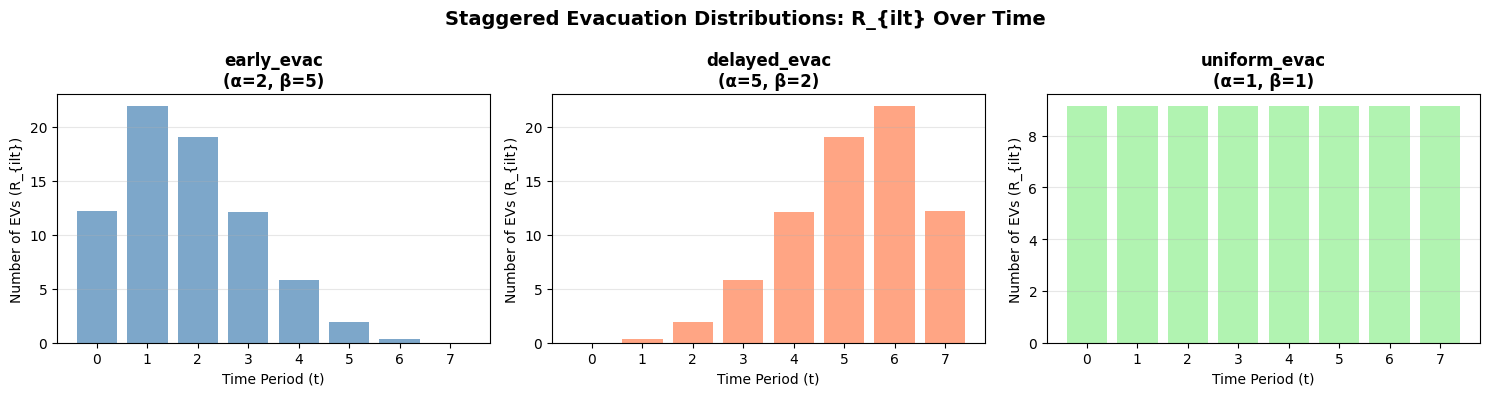

Visualization saved to ../output/staggered_evacuation_distributions.png


In [16]:
# Visualize evacuation profiles across time for all three scenarios
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Staggered Evacuation Distributions: R_{ilt} Over Time', fontsize=14, fontweight='bold')

for idx, (scenario_name, R_ilt) in enumerate(R_distributions.items()):
    # Sum over all nodes and charge levels to get evacuation profile over time
    evacuation_profile = np.sum(R_ilt, axis=(0, 1))
    
    axes[idx].bar(range(len(evacuation_profile)), evacuation_profile, color=['steelblue', 'coral', 'lightgreen'][idx], alpha=0.7)
    axes[idx].set_title(f'{scenario_name}\n(α={scenarios[scenario_name]["alpha"]}, β={scenarios[scenario_name]["beta"]})', fontweight='bold')
    axes[idx].set_xlabel('Time Period (t)')
    axes[idx].set_ylabel('Number of EVs (R_{ilt})')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../output/staggered_evacuation_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved to ../output/staggered_evacuation_distributions.png")


## Stochastic Optimization Model with Staggered Evacuation

This section implements the two-stage stochastic optimization model with staggered evacuation constraints:

**Flow Balance Constraints (with R_{ilt})**:

For intermediate charge levels (l ∉ {0, L}):
$$\sum_{(i,j) \in \mathcal{A}} x_{ijlt}^w + y_{jlt}^w + z_{jlt}^w + R_{jlt} = \sum_{(j,k) \in \mathcal{A}} x_{jk,l-1,t+1}^w + y_{j,l+1,t+1}^w + z_{jl,t+1}^w$$

For maximum charge level (l = L):
$$y_{j,L,t}^w + z_{j,L,t}^w + R_{j,L,t} = \sum_{(j,k) \in \mathcal{A}} x_{jk,L-1,t+1}^w + z_{jL,t+1}^w$$

For zero charge level (l = 0):
$$z_{j,0,t}^w + \sum_{(i,j) \in \mathcal{A}} x_{ij,0,t}^w + R_{j,0,t} = z_{j0,t+1}^w + y_{j,1,t+1}^w$$

**Initialization Constraint (z at t=0)**:
$$z_{il0}^w = R_{il0}$$


In [17]:
# Optimization model function with staggered evacuation (R_ilt)
def primal_run_staggered(
    L, T, cases_num, N, N_s, A, car_num, R_ilt_dict, node_list, road_ca, xi_s, Vi, Vo, B, G, 
    Outputpath, out_folder_name, out_folder, Total_cars, scenario_name=""
):
    """
    Solve two-stage stochastic optimization with staggered evacuation.
    
    Parameters:
    - R_ilt_dict: Dictionary mapping scenario names to R_ilt arrays
    - All other parameters as before
    """
    start = time.time()
    model = pe.ConcreteModel()

    # Model settings
    model.Levels = range(L)
    model.Times = range(4*T+1)
    model.ReleaseTimes = range(4*T)
    model.Cases = range(cases_num)

    model.nodes = pe.Set(initialize=N)
    model.nodes_safe = pe.Set(initialize=N_s)
    model.edges = pe.Set(initialize=A)

    # Parameters: car number initialization
    model.car_num = pe.Param(model.Levels, model.nodes, initialize=car_num)
    
    # Parameters: staggered evacuation R_ilt for current scenario
    # Convert R_ilt array to dictionary format for Pyomo
    R_ilt_param = {}
    R_ilt_current = R_ilt_dict[scenario_name]  # Get R_ilt for current scenario
    for node_idx, node in enumerate(node_list):
        for l in model.Levels:
            for t in model.ReleaseTimes:
                R_ilt_param[(l, node, t)] = float(R_ilt_current[node_idx, l, t])

    model.R_ilt = pe.Param(
        model.Levels,
        model.nodes,
        model.ReleaseTimes,
        initialize=R_ilt_param,
        within=pe.NonNegativeReals
    )

    
    # Road capacity
    model.road_ca = pe.Param(model.edges, model.Cases, model.Times, initialize=road_ca)
    # Charging capacity random damage factor
    model.char_damFac = pe.Param(model.nodes, model.Cases, model.Times, initialize=xi_s)
    # Scenario probabilities
    model.prob = pe.Param(model.Cases, initialize=prob_dict)

    # Define incoming and outgoing sets
    model.Vi = pe.Param(model.nodes, initialize=Vi, default=set(), within=pe.Any)
    model.Vo = pe.Param(model.nodes, initialize=Vo, default=set(), within=pe.Any)

    # VARIABLES
    model.x = pe.Var(model.Levels, model.edges, model.Times, model.Cases, within=pe.NonNegativeReals)
    model.y = pe.Var(model.Levels, model.nodes, model.Times, model.Cases, within=pe.NonNegativeReals)
    model.z = pe.Var(model.Levels, model.nodes, model.Times, model.Cases, within=pe.NonNegativeReals)
    model.s = pe.Var(model.nodes, within=pe.NonNegativeReals)

    # OBJECTIVE VALUE
    obj_func_value = 0

    # CONSTRAINT LISTS
    model.con_flow_bal = pe.ConstraintList()
    model.con_charge_limit = pe.ConstraintList()
    model.con_road_ca = pe.ConstraintList()
    model.budget_con = pe.ConstraintList()
    model.con_x_init = pe.ConstraintList()
    model.con_y_init = pe.ConstraintList()
    model.con_y = pe.ConstraintList()
    model.con_z_init = pe.ConstraintList()

    # 1st stage constraint: BUDGET OF INVESTMENT
    total_budget_expr = sum(G * model.s[j] for j in model.nodes)
    model.budget_con.add(expr=(total_budget_expr <= B))

    # 2nd stage constraints
    for w in range(cases_num):
        # Objective function value
        obj_func_value += model.prob[w] * -sum(
            sum(
                sum(model.z[l, j, t, w] for j in model.nodes_safe) +
                sum(model.y[l, j, t, w] for j in model.nodes_safe)
                for l in model.Levels
            )
            for t in model.Times
        )

        # FLOW BALANCE CONSTRAINTS with R_ilt (staggered evacuation)
        for j in model.nodes:
            for t in range(4*T):
                for l in model.Levels:
                    release_at_t = 0 if t == 0 else model.R_ilt[l, j, t]
                    # Intermediate charge levels (l not in {0, L})
                    if l >= 1 and l <= L-2:
                        flow_in = (
                            sum(model.x[l, i, j, t, w] for i in model.Vi[j]) +
                            model.y[l, j, t, w] +
                            model.z[l, j, t, w] +
                            release_at_t  # STAGGERED START: R_ilt added to inflow
                        )
                        flow_out = (
                            model.y[l+1, j, t+1, w] +
                            model.z[l, j, t+1, w] +
                            sum(model.x[l-1, j, k, t+1, w] for k in model.Vo[j] if k != j)
                        )
                        model.con_flow_bal.add(expr=(flow_in == flow_out))

                    # Minimum charge level (l = 0)
                    if l == 0:
                        flow_in = (
                            sum(model.x[l, i, j, t, w] for i in model.Vi[j]) +
                            model.z[l, j, t, w] +
                            release_at_t  # STAGGERED START: R_ilt added to inflow
                        )
                        flow_out = (
                            model.y[l+1, j, t+1, w] +
                            model.z[l, j, t+1, w]
                        )
                        model.con_flow_bal.add(expr=(flow_in == flow_out))

                    # Maximum charge level (l = L-1)
                    if l == L-1:
                        flow_in = (
                            model.y[l, j, t, w] +
                            model.z[l, j, t, w] +
                            release_at_t  # STAGGERED START: R_ilt added to inflow
                        )
                        flow_out = (
                            sum(model.x[l-1, j, k, t+1, w] for k in model.Vo[j] if k != j) +
                            model.z[l, j, t+1, w]
                        )
                        model.con_flow_bal.add(expr=(flow_in == flow_out))

        # CHARGING LIMIT constraint
        for j in model.nodes:
            for t in model.Times:
                LHS = sum(model.y[l, j, t, w] for l in range(1, L))
                RHS = model.s[j] * model.char_damFac[j, w, t]
                model.con_charge_limit.add(expr=(LHS <= RHS))

        # ROAD CAPACITY constraint
        for (i, j) in model.edges:
            for t in model.Times:
                if i != j:
                    LHS = sum(model.x[l, i, j, t, w] for l in range(L-1))
                    RHS = model.road_ca[i, j, w, t]
                    model.con_road_ca.add(expr=(LHS <= RHS))

        # x INITIALIZATION
        for (i, j) in model.edges:
            for t in model.Times:
                con_expr = (model.x[L-1, i, j, t, w] == 0)
                model.con_x_init.add(expr=con_expr)
            for l in model.Levels:
                con_expr = (model.x[l, i, j, 0, w] == 0)
                model.con_x_init.add(expr=con_expr)

        # y INITIALIZATION
        for j in model.nodes:
            for l in model.Levels:
                con_expr = (model.y[l, j, 0, w] == 0)
                model.con_y_init.add(expr=con_expr)

        # z INITIALIZATION: z_{il0}^w = R_{il0} (STAGGERED START CONSTRAINT)
        for j in model.nodes:
            for l in model.Levels:
                con_expr = (model.z[l, j, 0, w] == model.R_ilt[l, j, 0])
                model.con_z_init.add(expr=con_expr)

        # y constraint for l = 0: cannot charge to level 0
        for j in model.nodes:
            for t in model.Times:
                y_con_expr = (model.y[0, j, t, w] == 0)
                model.con_y.add(expr=y_con_expr)

    model.obj_max_reward = pe.Objective(sense=pe.minimize, expr=obj_func_value)

    # Solve
    result = solver.solve(model, tee=True)

    end = time.time()
    run_time = end - start
    print(f"Execution time: {run_time:.2f} seconds")

    # POST PROCESSING
    s_output = {'Nodes': [], 'CharCap': []}
    for j in model.nodes:
        s_output['Nodes'].append(j)
        s_output['CharCap'].append(model.s[j].value)
    df_s_output = pd.DataFrame(s_output)

    x_output = {'Arcs': [], 'Levels': [], 'Times': [], 'Scenarios': [], 'NumCars': []}
    y_output = {'Nodes': [], 'Levels': [], 'Times': [], 'Scenarios': [], 'NumCars': []}
    z_output = {'Nodes': [], 'Levels': [], 'Times': [], 'Scenarios': [], 'NumCars': []}

    for (i, j) in model.edges:
        for l in model.Levels:
            for t in model.Times:
                for w in model.Cases:
                    x_output['Arcs'].append((i, j))
                    x_output['Levels'].append(l)
                    x_output['Times'].append(t)
                    x_output['Scenarios'].append(w)
                    x_output['NumCars'].append(model.x[l, i, j, t, w].value)

    for j in model.nodes:
        for l in model.Levels:
            for t in model.Times:
                for w in model.Cases:
                    y_output['Nodes'].append(j)
                    z_output['Nodes'].append(j)
                    y_output['Levels'].append(l)
                    z_output['Levels'].append(l)
                    y_output['Times'].append(t)
                    z_output['Times'].append(t)
                    y_output['Scenarios'].append(w)
                    z_output['Scenarios'].append(w)
                    y_output['NumCars'].append(model.y[l, j, t, w].value)
                    z_output['NumCars'].append(model.z[l, j, t, w].value)

    df_x_output = pd.DataFrame(x_output)
    df_y_output = pd.DataFrame(y_output)
    df_z_output = pd.DataFrame(z_output)

    # Save outputs
    if not os.path.exists(out_folder):
        os.makedirs(out_folder)

    df_s_output.to_csv(os.path.join(out_folder, "s_values.csv"), index=False)
    df_x_output.to_csv(os.path.join(out_folder, "x_values.csv"), index=False)
    df_y_output.to_csv(os.path.join(out_folder, "y_values.csv"), index=False)
    df_z_output.to_csv(os.path.join(out_folder, "z_values.csv"), index=False)

    # Calculate evacuation metrics
    num_evac = sum(
        model.prob[w] *
        sum(
            sum((model.y[l, j, 4*T, w].value + model.z[l, j, 4*T, w].value)
                for j in model.nodes_safe)
            for l in model.Levels
        )
        for w in model.Cases
    )

    avg_time = {}
    avg_time_all = {}
    for w in model.Cases:
        suc_cars = sum(
            sum((model.y[l, j, 4*T, w].value + model.z[l, j, 4*T, w].value)
                for j in model.nodes_safe)
            for l in model.Levels
        )
        avg_time[w] = 0
        for t in model.Times:
            if t >= 1:
                avg_time[w] = avg_time[w] + t * (
                    sum(
                        sum((model.y[l, j, t, w].value + model.z[l, j, t, w].value)
                            for j in model.nodes_safe)
                        for l in model.Levels
                    ) -
                    sum(
                        sum((model.y[l, j, t-1, w].value + model.z[l, j, t-1, w].value)
                            for j in model.nodes_safe)
                        for l in model.Levels
                    )
                )
        avg_time_all[w] = (avg_time[w] + (4*T) * (Total_cars - suc_cars)) / Total_cars
        if suc_cars > 0:
            avg_time[w] = avg_time[w] / suc_cars
        else:
            avg_time[w] = 0

    avg_evac_time = sum((model.prob[w] * avg_time[w]) for w in model.Cases)
    avg_evac_time_all = sum((model.prob[w] * avg_time_all[w]) for w in model.Cases)

    return num_evac, avg_evac_time, avg_evac_time_all, run_time


## Run Matched Staggered-Start Scenarios

This section runs the staggered-start cases using the same fixed setup as the base case. The only intended change is the evacuation release profile `R_ilt`.


In [18]:
# Matched experiment parameters
# Keep B and T fixed here so the staggered-start cases are comparable with the base case.
# To run a broader budget/time sensitivity later, wrap the scenario loop below in B/T loops.
Total_cars = 73.203  # Total number of EVs to evacuate, in thousand cars

print(f"Matched budget B: {B} million dollars")
print(f"Matched evacuation time window T: {T} hours")
print(f"Total EVs: {Total_cars} thousand cars")


Matched budget B: 10 million dollars
Matched evacuation time window T: 2 hours
Total EVs: 73.203 thousand cars


In [19]:
# Run optimization for all selected staggered-start scenarios
# Edit this list if you only want to run a subset.
scenarios_to_run = ["uniform_evac", "early_evac", "delayed_evac"]

staggered_results = []
staggered_output_root = os.path.join(Outputpath, "staggered_start")
os.makedirs(staggered_output_root, exist_ok=True)

for scenario_to_run in scenarios_to_run:
    print(f"\nRunning optimization for scenario: {scenario_to_run}")
    print("=" * 80)

    out_folder_name = f"staggered_start_{scenario_to_run}_B{B}_T{T}"
    out_folder = os.path.join(staggered_output_root, out_folder_name)

    num_evac, avg_evac_time, avg_evac_time_all, run_time = primal_run_staggered(
        L=L,
        T=T,
        cases_num=cases_num,
        N=N,
        N_s=N_s,
        A=A,
        car_num=car_num,
        R_ilt_dict=R_distributions,
        node_list=node_list,
        road_ca=road_ca,
        xi_s=xi_s,
        Vi=Vi,
        Vo=Vo,
        B=B,
        G=G,
        Outputpath=Outputpath,
        out_folder_name=out_folder_name,
        out_folder=out_folder,
        Total_cars=Total_cars,
        scenario_name=scenario_to_run,
    )

    staggered_results.append({
        "Scenario": scenario_to_run,
        "B": B,
        "EvacTime": T,
        "NumEvac": num_evac,
        "Avg_evac_time": avg_evac_time,
        "Avg_evac_time_all": avg_evac_time_all,
        "RunTime": run_time,
        "OutputFolder": out_folder,
    })

    print(f"\nResults for {scenario_to_run}:")
    print(f"  Number of EVs evacuated: {num_evac:.2f}")
    print(f"  Average evacuation time (successful): {avg_evac_time:.2f}")
    print(f"  Average evacuation time (all): {avg_evac_time_all:.2f}")
    print(f"  Run time: {run_time:.2f} seconds")

staggered_results_df = pd.DataFrame(staggered_results)
staggered_results_csv = os.path.join(staggered_output_root, f"staggered_scenario_results_B{B}_T{T}.csv")
staggered_results_df.to_csv(staggered_results_csv, index=False)

print("\nAll selected staggered scenarios finished.")
print(f"Saved summary results to {staggered_results_csv}")
display(staggered_results_df)



Running optimization for scenario: uniform_evac
source (type: set).  This WILL potentially lead to nondeterministic behavior
in Pyomo
data source (type: set).  This WILL potentially lead to nondeterministic
behavior in Pyomo
source (type: set).  This WILL potentially lead to nondeterministic behavior
in Pyomo
Read LP format model from file /var/folders/w6/hlw3gptn62s2rz_xj4tjg3tc0000gn/T/tmp74mqdauh.pyomo.lp
Reading time = 1.12 seconds
x1: 207361 rows, 563786 columns, 1478116 nonzeros
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[rosetta2] - Darwin 25.4.0 25E253)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 207361 rows, 563786 columns and 1478116 nonzeros
Model fingerprint: 0xbfdaa14b
Coefficient statistics:
  Matrix range     [1e+00, 4e+00]
  Objective range  [5e-02, 5e-02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e-06, 1e+01]
Presolve removed 135659 rows and 327276 columns
Presolve tim

,Scenario,B,EvacTime,NumEvac,Avg_evac_time,Avg_evac_time_all,RunTime,OutputFolder
0,uniform_evac,10,2,43.120422,5.869597,6.745111,16.617264,../output/numerical_results/staggered_start/st...
1,early_evac,10,2,58.742125,5.643996,6.109430,16.830942,../output/numerical_results/staggered_start/st...
2,delayed_evac,10,2,22.628669,7.151611,7.737747,16.018382,../output/numerical_results/staggered_start/st...


## Plot Staggered Start Sensitivity Results

Plot the optimization results of the staggered start sensitivity analysis below. Three types of figures will be generated: installed charging capacity maps (Cartopy), cumulative evacuation curves, and performance comparison plots. 


In [81]:
import importlib
import optimization_result_plotting
importlib.reload(optimization_result_plotting)
from optimization_result_plotting import (
    plot_capacity_multiple,
    plot_cumulative_curve,
    plot_performance
)

In [ ]:
# Build scneario mapping
result_folders = {
    "base_case": "../output/numerical_results/even_battery_normal_speed/B10T2evenL27/",
    **{
        row["Scenario"]: row["OutputFolder"] for _, row in staggered_results_df.iterrows()
    }
}

# --- Installed charging capacity maps ---
plot_capacity_multiple(
    result_folders,
    df_node,
    df_arc,
    global_vmin=0,
    global_vmax=2,
    save_dir="../output/figures/capacity_maps"
)

# --- Cumulative evacuation curves ---
plot_cumulative_curve(
    result_folders,
    N_s,
    prob_dict,
    Total_cars,
    scenario_order=["base_case", "early_evac", "uniform_evac", "delayed_evac"],
    scenario_labels={
        "base_case": "Base case",
        "early_evac": "Early staggered",
        "uniform_evac": "Uniform staggered",
        "delayed_evac": "Delayed staggered",
    }
)

# --- Performance comparison ---
plot_performance(
    result_folders,
    N_s,
    prob_dict,
    Total_cars,
    T,
    scenario_order=["base_case", "early_evac", "uniform_evac", "delayed_evac"],
    scenario_labels={
        "base_case": "Base case",
        "early_evac": "Early staggered",
        "uniform_evac": "Uniform staggered",
        "delayed_evac": "Delayed staggered",
    }
)

TypeError: plot_capacity_multiple() got an unexpected keyword argument 'vmin'